## Imports & Load Data ##

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
import os
os.makedirs('images', exist_ok=True)
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:,.2f}'.format)
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

# Load data
pipeline = pd.read_csv(r"C:\Users\akskumari\Desktop\CRM_FUNNEL_Project\CRM+Sales+Opportunities\sales_pipeline.csv", parse_dates=['engage_date', 'close_date'])
accounts = pd.read_csv(r"C:\Users\akskumari\Desktop\CRM_FUNNEL_Project\CRM+Sales+Opportunities\accounts.csv")
products = pd.read_csv(r"C:\Users\akskumari\Desktop\CRM_FUNNEL_Project\CRM+Sales+Opportunities\products.csv")
teams = pd.read_csv(r"C:\Users\akskumari\Desktop\CRM_FUNNEL_Project\CRM+Sales+Opportunities\sales_teams.csv")

# Fix revenue column — has commas, stored as string
accounts['revenue'] = accounts['revenue'].astype(str).str.replace(',', '').astype(float)
pipeline['close_value'] = pipeline['close_value'].astype(str).str.replace(',', '').astype(float)

print("Pipeline:", pipeline.shape)
print("Teams columns:", teams.columns.tolist())
print("Stages:", pipeline['deal_stage'].unique())

Pipeline: (8800, 8)
Teams columns: ['sales_agent', 'manager', 'regional_office']
Stages: ['Won' 'Engaging' 'Lost' 'Prospecting']


## Data Quality Check ##

In [38]:
print("=== NULL CHECK ===")
print(pipeline.isnull().sum())

print("\n=== DTYPES ===")
print(pipeline.dtypes)

print("\n=== STAGE DISTRIBUTION ===")
print(pipeline['deal_stage'].value_counts())

=== NULL CHECK ===
opportunity_id       0
sales_agent          0
product              0
account           1425
deal_stage           0
engage_date        500
close_date        2089
close_value       2089
dtype: int64

=== DTYPES ===
opportunity_id            object
sales_agent               object
product                   object
account                   object
deal_stage                object
engage_date       datetime64[ns]
close_date        datetime64[ns]
close_value              float64
dtype: object

=== STAGE DISTRIBUTION ===
deal_stage
Won            4238
Lost           2473
Engaging       1589
Prospecting     500
Name: count, dtype: int64


## Funnel Analysis (Stage Conversion) ##

,stage,count,pct_of_total,conversion_from_prev
0,Prospecting,500,5.68,NaN
1,Engaging,1589,18.06,317.80
2,Won,4238,48.16,266.71
3,Lost,2473,28.10,58.35


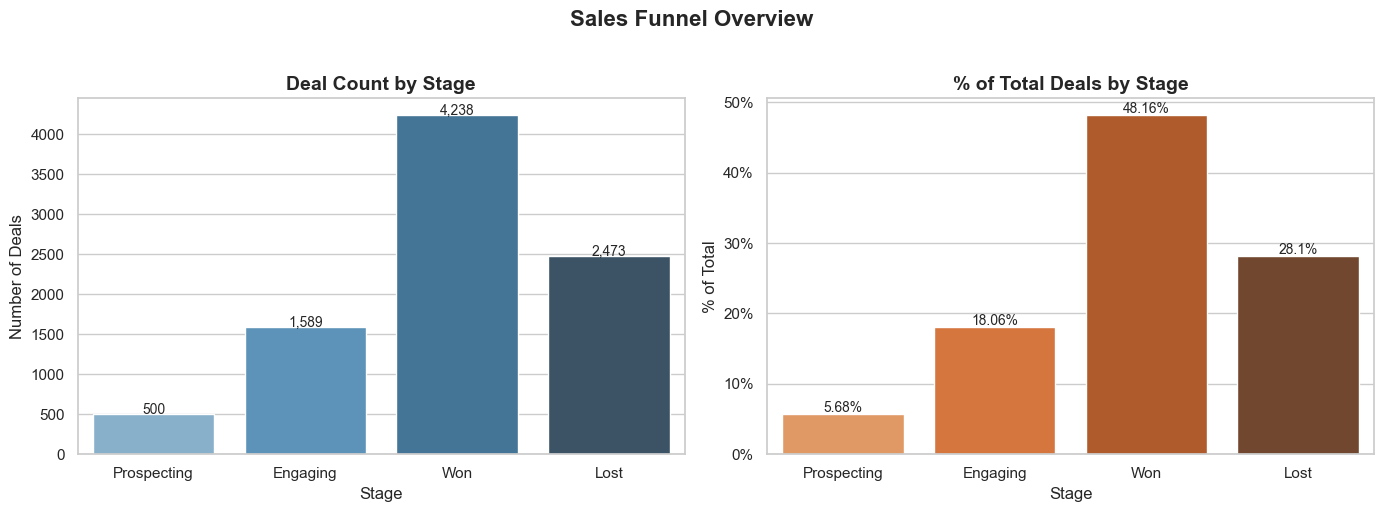

In [41]:
# Define funnel order
funnel_order = ['Prospecting', 'Engaging', 'Won', 'Lost']

stage_counts = (
    pipeline['deal_stage']
    .value_counts()
    .reindex(funnel_order)
    .reset_index()
)
stage_counts.columns = ['stage', 'count']
stage_counts['pct_of_total'] = (stage_counts['count'] / stage_counts['count'].sum() * 100).round(2)

# Conversion rate between consecutive stages
stage_counts['conversion_from_prev'] = (
    stage_counts['count'] / stage_counts['count'].shift(1) * 100
).round(2)

display(stage_counts)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
sns.barplot(data=stage_counts, x='stage', y='count', palette='Blues_d', ax=axes[0])
axes[0].set_title('Deal Count by Stage', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Stage')
axes[0].set_ylabel('Number of Deals')
for bar, val in zip(axes[0].patches, stage_counts['count']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'{val:,}', ha='center', fontsize=10)

# % of total
sns.barplot(data=stage_counts, x='stage', y='pct_of_total', palette='Oranges_d', ax=axes[1])
axes[1].set_title('% of Total Deals by Stage', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Stage')
axes[1].set_ylabel('% of Total')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
for bar, val in zip(axes[1].patches, stage_counts['pct_of_total']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val}%', ha='center', fontsize=10)

plt.suptitle('Sales Funnel Overview', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('images/01_funnel_overview.png', dpi=150, bbox_inches='tight')
plt.show()

## Win Rate by Product ##

,product,total_deals,won,lost,avg_close_value,win_rate
3,GTX Plus Pro,968,479,266,"3,529.73",49.48
4,GTXPro,1480,729,418,"3,060.66",49.26
1,GTX Basic,1866,915,521,347.68,49.04
6,MG Special,1651,793,430,35.79,48.03
2,GTX Plus Basic,1383,653,398,671.05,47.22
5,MG Advanced,1412,654,430,"2,044.64",46.32
0,GTK 500,40,15,10,"16,024.48",37.50


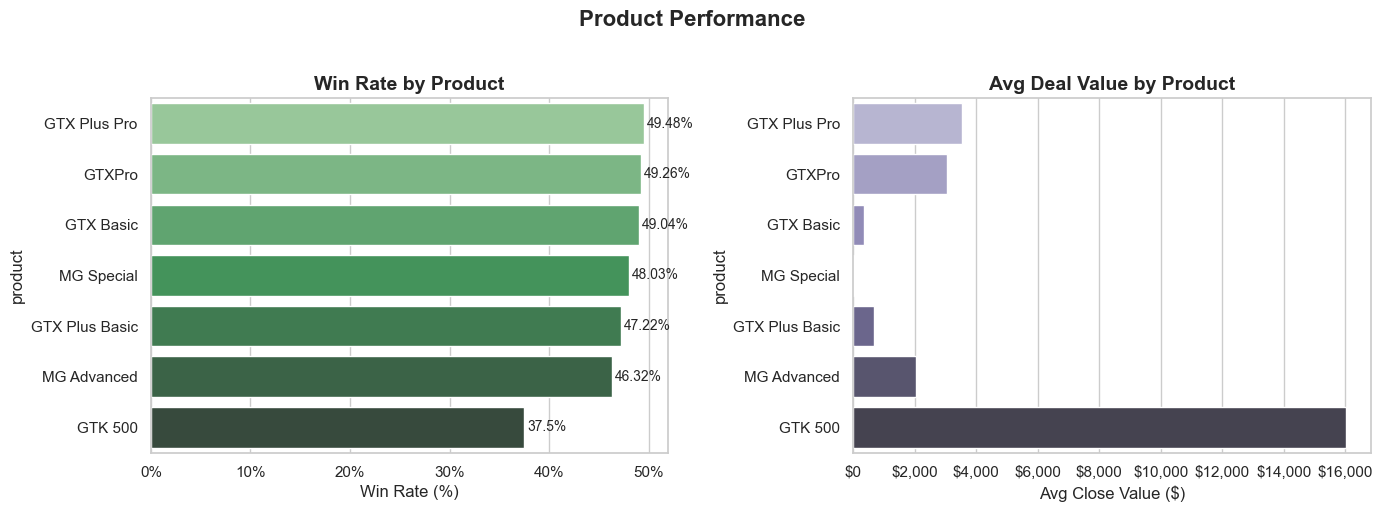

In [43]:
merged = pipeline.merge(products, on='product', how='left')

product_funnel = (
    merged.groupby('product')
    .agg(
        total_deals=('deal_stage', 'count'),
        won=('deal_stage', lambda x: (x == 'Won').sum()),
        lost=('deal_stage', lambda x: (x == 'Lost').sum()),
        avg_close_value=('close_value', 'mean')
    )
    .reset_index()
)
product_funnel['win_rate'] = (product_funnel['won'] / product_funnel['total_deals'] * 100).round(2)
product_funnel = product_funnel.sort_values('win_rate', ascending=False)

display(product_funnel)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=product_funnel, x='win_rate', y='product', palette='Greens_d', ax=axes[0])
axes[0].set_title('Win Rate by Product', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Win Rate (%)')
axes[0].xaxis.set_major_formatter(mtick.PercentFormatter())
for bar, val in zip(axes[0].patches, product_funnel['win_rate']):
    axes[0].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{val}%', va='center', fontsize=10)

sns.barplot(data=product_funnel, x='avg_close_value', y='product', palette='Purples_d', ax=axes[1])
axes[1].set_title('Avg Deal Value by Product', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Avg Close Value ($)')
axes[1].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.suptitle('Product Performance', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('images/02_product_win_rate.png', dpi=150, bbox_inches='tight')
plt.show()

##  Sales Team Leaderboard ##

,manager,total_deals,won,lost,avg_deal_value,win_rate,total_revenue
4,Rocco Neubert,1327,691,422,"1,761.50",52.07,"1,960,545.00"
0,Cara Losch,964,480,265,"1,516.84",49.79,"1,130,049.00"
5,Summer Sewald,1701,828,459,"1,526.61",48.68,"1,964,750.00"
2,Dustin Brinkmann,1583,747,439,922.73,47.19,"1,094,363.00"
1,Celia Rouche,1296,610,352,"1,667.25",47.07,"1,603,897.00"
3,Melvin Marxen,1929,882,536,"1,588.10",45.72,"2,251,930.00"


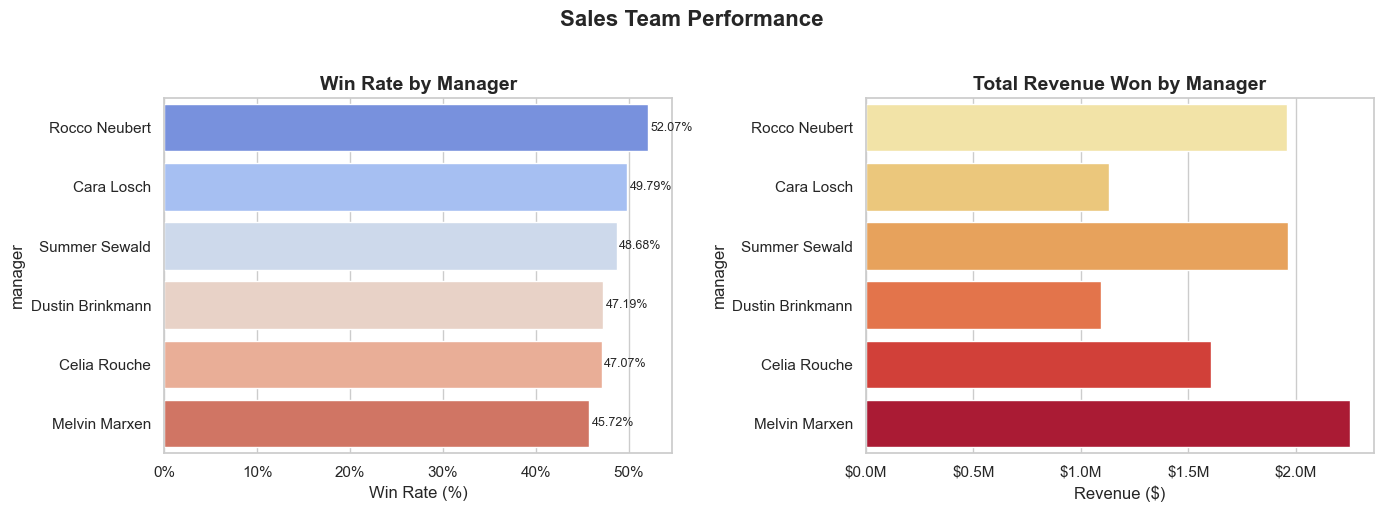

In [44]:
merged2 = pipeline.merge(teams, on='sales_agent', how='left')

team_perf = (
    merged2.groupby('manager')
    .agg(
        total_deals=('deal_stage', 'count'),
        won=('deal_stage', lambda x: (x == 'Won').sum()),
        lost=('deal_stage', lambda x: (x == 'Lost').sum()),
        avg_deal_value=('close_value', 'mean')
    )
    .reset_index()
)
team_perf['win_rate'] = (team_perf['won'] / team_perf['total_deals'] * 100).round(2)
team_perf['total_revenue'] = (
    merged2[merged2['deal_stage'] == 'Won']
    .groupby('manager')['close_value']
    .sum()
    .values
)
team_perf = team_perf.sort_values('win_rate', ascending=False)

display(team_perf)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=team_perf, x='win_rate', y='manager', palette='coolwarm', ax=axes[0])
axes[0].set_title('Win Rate by Manager', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Win Rate (%)')
axes[0].xaxis.set_major_formatter(mtick.PercentFormatter())
for bar, val in zip(axes[0].patches, team_perf['win_rate']):
    axes[0].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{val}%', va='center', fontsize=9)

sns.barplot(data=team_perf, x='total_revenue', y='manager', palette='YlOrRd', ax=axes[1])
axes[1].set_title('Total Revenue Won by Manager', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Revenue ($)')
axes[1].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))

plt.suptitle('Sales Team Performance', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('images/03_team_leaderboard.png', dpi=150, bbox_inches='tight')
plt.show()

## Deal Velocity (How Long Deals Take) ##

,stage,avg_days,median_days,std_days,count
0,Lost,41.50,14.00,40.00,2473
1,Won,51.80,57.00,41.20,4238


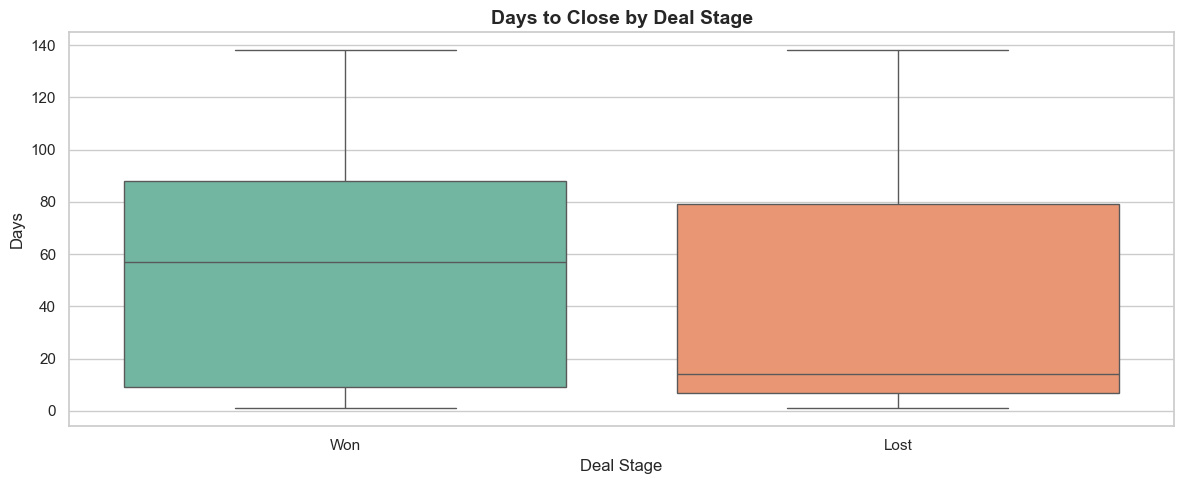

In [45]:
# Only use rows where both dates exist
velocity = pipeline.dropna(subset=['engage_date', 'close_date']).copy()
velocity['days_to_close'] = (velocity['close_date'] - velocity['engage_date']).dt.days

velocity_summary = (
    velocity.groupby('deal_stage')['days_to_close']
    .agg(['mean', 'median', 'std', 'count'])
    .round(1)
    .reset_index()
)
velocity_summary.columns = ['stage', 'avg_days', 'median_days', 'std_days', 'count']

display(velocity_summary)

# Box plot
plt.figure(figsize=(12, 5))
sns.boxplot(data=velocity, x='deal_stage', y='days_to_close', palette='Set2')
plt.title('Days to Close by Deal Stage', fontsize=14, fontweight='bold')
plt.xlabel('Deal Stage')
plt.ylabel('Days')
plt.tight_layout()
plt.savefig('images/04_deal_velocity.png', dpi=150, bbox_inches='tight')
plt.show()

## Quarter-over-Quarter Trend ##

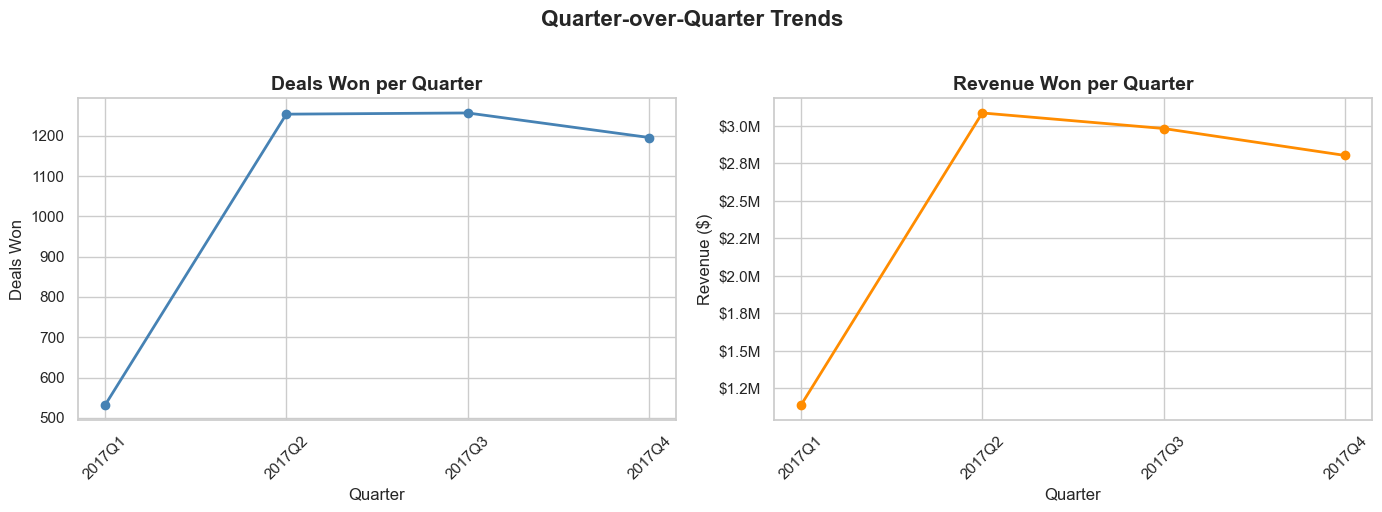

In [46]:
won_deals = pipeline[pipeline['deal_stage'] == 'Won'].copy()
won_deals['close_quarter'] = won_deals['close_date'].dt.to_period('Q').astype(str)

qoq = (
    won_deals.groupby('close_quarter')
    .agg(
        deals_won=('deal_stage', 'count'),
        revenue=('close_value', 'sum')
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(qoq['close_quarter'], qoq['deals_won'], marker='o', color='steelblue', linewidth=2)
axes[0].set_title('Deals Won per Quarter', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Quarter')
axes[0].set_ylabel('Deals Won')
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(qoq['close_quarter'], qoq['revenue'], marker='o', color='darkorange', linewidth=2)
axes[1].set_title('Revenue Won per Quarter', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Quarter')
axes[1].set_ylabel('Revenue ($)')
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Quarter-over-Quarter Trends', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('images/05_qoq_trend.png', dpi=150, bbox_inches='tight')
plt.show()

## Executive Summary (Print as Text) ##

In [47]:
total    = len(pipeline)
won      = (pipeline['deal_stage'] == 'Won').sum()
lost     = (pipeline['deal_stage'] == 'Lost').sum()
win_rate = round(won / total * 100, 1)
total_rev = pipeline.loc[pipeline['deal_stage'] == 'Won', 'close_value'].sum()
best_product = product_funnel.iloc[0]['product']
best_manager = team_perf.iloc[0]['manager']

print("=" * 50)
print("       SALES FUNNEL — EXECUTIVE SUMMARY")
print("=" * 50)
print(f"  Total Deals in Pipeline  : {total:,}")
print(f"  Deals Won                : {won:,}")
print(f"  Deals Lost               : {lost:,}")
print(f"  Overall Win Rate         : {win_rate}%")
print(f"  Total Revenue Won        : ${total_rev:,.0f}")
print(f"  Best Performing Product  : {best_product}")
print(f"  Top Sales Manager        : {best_manager}")
print("=" * 50)

       SALES FUNNEL — EXECUTIVE SUMMARY
  Total Deals in Pipeline  : 8,800
  Deals Won                : 4,238
  Deals Lost               : 2,473
  Overall Win Rate         : 48.2%
  Total Revenue Won        : $10,005,534
  Best Performing Product  : GTX Plus Pro
  Top Sales Manager        : Rocco Neubert


## Imports & Setup ##

In [48]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

# pip install xgboost if needed

##  Feature Engineering ##

In [49]:
# Keep only Won/Lost deals — drop Prospecting/Engaging (no outcome yet)
df = pipeline[pipeline['deal_stage'].isin(['Won', 'Lost'])].copy()

# Target variable
df['target'] = (df['deal_stage'] == 'Won').astype(int)

# Feature 1: Days to close
df['days_to_close'] = (df['close_date'] - df['engage_date']).dt.days

# Feature 2: Engage month (seasonality signal)
df['engage_month'] = df['engage_date'].dt.month

# Feature 3: Engage quarter
df['engage_quarter'] = df['engage_date'].dt.quarter

# Merge in team and product info
df = df.merge(teams, on='sales_agent', how='left')
df = df.merge(products, on='product', how='left')

# Feature 4: Close value (deal size)
df['close_value'] = df['close_value'].fillna(0)

# Select features
features = [
    'close_value',
    'days_to_close',
    'engage_month',
    'engage_quarter',
    'product',
    'sales_agent',
    'manager',
    'office_location',   # from accounts if available
    'sector'             # from accounts if available
]

# Merge accounts for sector/location
df = df.merge(accounts[['account', 'office_location', 'sector', 'revenue', 'employees']],
              on='account', how='left')

# Final feature list (only cols that exist)
feature_cols = [
    'close_value', 'days_to_close', 'engage_month', 'engage_quarter',
    'product', 'manager', 'office_location', 'sector', 'revenue', 'employees'
]
feature_cols = [c for c in feature_cols if c in df.columns]

print("Features used:", feature_cols)
print("Dataset shape:", df[feature_cols].shape)
print("Target distribution:\n", df['target'].value_counts())

Features used: ['close_value', 'days_to_close', 'engage_month', 'engage_quarter', 'product', 'manager', 'office_location', 'sector', 'revenue', 'employees']
Dataset shape: (6711, 10)
Target distribution:
 target
1    4238
0    2473
Name: count, dtype: int64


## Encode Categoricals ##

In [50]:
df_model = df[feature_cols + ['target']].copy()

# Fill nulls
df_model['days_to_close'] = df_model['days_to_close'].fillna(df_model['days_to_close'].median())
df_model['revenue']       = df_model['revenue'].fillna(0)
df_model['employees']     = df_model['employees'].fillna(0)

# Label encode all categorical columns
cat_cols = df_model.select_dtypes(include='object').columns.tolist()
le = LabelEncoder()

for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

print("Null check after encoding:")
print(df_model.isnull().sum())

df_model.head()

Null check after encoding:
close_value        0
days_to_close      0
engage_month       0
engage_quarter     0
product            0
manager            0
office_location    0
sector             0
revenue            0
employees          0
target             0
dtype: int64


,close_value,days_to_close,engage_month,engage_quarter,product,manager,office_location,sector,revenue,employees,target
0,"1,054.00",132,10,4,2,2,14,5,718.62,2448,1
1,"4,514.00",137,10,4,4,3,14,4,"3,178.24",4540,1
2,50.00,133,10,4,6,3,14,5,718.62,2448,1
3,588.00,135,10,4,1,2,14,7,"2,714.90",2641,1
4,517.00,128,10,4,1,5,14,6,792.46,1299,1


## Train / Test Split & Model ##

In [51]:
X = df_model.drop('target', axis=1)
y = df_model['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")
print(f"Win rate in train: {y_train.mean():.2%} | Win rate in test: {y_test.mean():.2%}")

# Train XGBoost
model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

model.fit(X_train, y_train)
print("\nModel trained")

Train size: 5368 | Test size: 1343
Win rate in train: 63.15% | Win rate in test: 63.14%

Model trained


## Train Multiple Classifiers ##

In [52]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (roc_auc_score, classification_report, 
                             confusion_matrix, ConfusionMatrixDisplay, roc_curve)
import time

# Define all models
models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest'       : RandomForestClassifier(random_state=42),
    'Gradient Boosting'   : GradientBoostingClassifier(random_state=42),
    'XGBoost'             : XGBClassifier(eval_metric='logloss', random_state=42),
    'KNN'                 : KNeighborsClassifier(),
    'SVM'                 : SVC(probability=True, random_state=42)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []

print("Training models...\n")
for name, model in models.items():
    start = time.time()
    
    cv_auc    = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc')
    cv_acc    = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')
    cv_f1     = cross_val_score(model, X_train, y_train, cv=cv, scoring='f1')
    
    model.fit(X_train, y_train)
    test_auc  = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    elapsed   = round(time.time() - start, 2)
    
    results.append({
        'Model'         : name,
        'CV AUC (mean)' : round(cv_auc.mean(), 4),
        'CV AUC (std)'  : round(cv_auc.std(), 4),
        'CV Accuracy'   : round(cv_acc.mean(), 4),
        'CV F1'         : round(cv_f1.mean(), 4),
        'Test AUC'      : round(test_auc, 4),
        'Train Time (s)': elapsed
    })
    print(f" {name:<25} CV AUC: {cv_auc.mean():.4f} ± {cv_auc.std():.4f} | Test AUC: {test_auc:.4f}")

results_df = pd.DataFrame(results).sort_values('Test AUC', ascending=False).reset_index(drop=True)
print("\n=== MODEL LEADERBOARD ===")
display(results_df)

Training models...

 Logistic Regression       CV AUC: 1.0000 ± 0.0000 | Test AUC: 1.0000
 Random Forest             CV AUC: 1.0000 ± 0.0000 | Test AUC: 1.0000
 Gradient Boosting         CV AUC: 1.0000 ± 0.0000 | Test AUC: 1.0000
 XGBoost                   CV AUC: 0.9998 ± 0.0001 | Test AUC: 0.9989
 KNN                       CV AUC: 0.9962 ± 0.0010 | Test AUC: 0.9963
 SVM                       CV AUC: 1.0000 ± 0.0000 | Test AUC: 1.0000

=== MODEL LEADERBOARD ===


,Model,CV AUC (mean),CV AUC (std),CV Accuracy,CV F1,Test AUC,Train Time (s)
0,Logistic Regression,1.00,0.00,1.00,1.00,1.00,1.34
1,Random Forest,1.00,0.00,1.00,1.00,1.00,7.59
2,Gradient Boosting,1.00,0.00,1.00,1.00,1.00,6.93
3,SVM,1.00,0.00,0.87,0.88,1.00,62.45
4,XGBoost,1.00,0.00,1.00,1.00,1.00,1.86
5,KNN,1.00,0.00,0.97,0.97,1.00,1.36


## Visualize Model Comparison ##

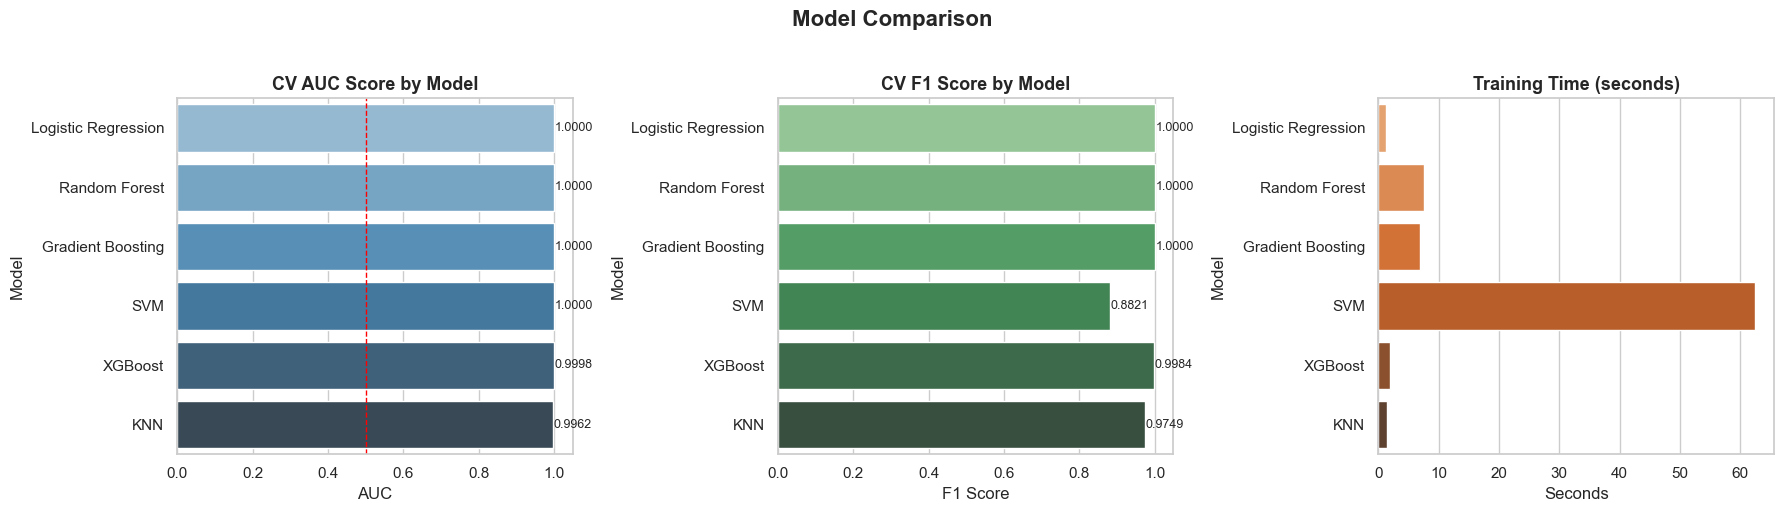

In [53]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# AUC comparison
sns.barplot(data=results_df, x='CV AUC (mean)', y='Model', palette='Blues_d', ax=axes[0])
axes[0].set_title('CV AUC Score by Model', fontsize=13, fontweight='bold')
axes[0].set_xlabel('AUC')
axes[0].axvline(0.5, color='red', linestyle='--', linewidth=1, label='Random baseline')
for bar, val in zip(axes[0].patches, results_df['CV AUC (mean)']):
    axes[0].text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=9)

# F1 comparison
sns.barplot(data=results_df, x='CV F1', y='Model', palette='Greens_d', ax=axes[1])
axes[1].set_title('CV F1 Score by Model', fontsize=13, fontweight='bold')
axes[1].set_xlabel('F1 Score')
for bar, val in zip(axes[1].patches, results_df['CV F1']):
    axes[1].text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=9)

# Train time
sns.barplot(data=results_df, x='Train Time (s)', y='Model', palette='Oranges_d', ax=axes[2])
axes[2].set_title('Training Time (seconds)', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Seconds')

plt.suptitle('Model Comparison', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('images/06_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

##  Hyperparameter Tuning (Top 2 Models) ##

In [54]:
from sklearn.model_selection import RandomizedSearchCV

# --- Tune Random Forest ---
rf_params = {
    'n_estimators'     : [100, 200, 300],
    'max_depth'        : [3, 5, 7, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'max_features'     : ['sqrt', 'log2']
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    n_iter=30,
    scoring='roc_auc',
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=0
)
rf_search.fit(X_train, y_train)
print("Random Forest best params:", rf_search.best_params_)
print(f"   Best CV AUC: {rf_search.best_score_:.4f}")

# --- Tune XGBoost ---
xgb_params = {
    'n_estimators'    : [100, 200, 300],
    'max_depth'       : [3, 4, 5, 6],
    'learning_rate'   : [0.01, 0.05, 0.1, 0.2],
    'subsample'       : [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5]
}

xgb_search = RandomizedSearchCV(
    XGBClassifier(eval_metric='logloss', random_state=42),
    xgb_params,
    n_iter=30,
    scoring='roc_auc',
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=0
)
xgb_search.fit(X_train, y_train)
print("\n XGBoost best params:", xgb_search.best_params_)
print(f"   Best CV AUC: {xgb_search.best_score_:.4f}")

Random Forest best params: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': None}
   Best CV AUC: 1.0000

 XGBoost best params: {'subsample': 0.6, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
   Best CV AUC: 0.9998


##  Evaluate Tuned Models ##


=== Random Forest (Tuned) ===
              precision    recall  f1-score   support

        Lost       1.00      1.00      1.00       495
         Won       1.00      1.00      1.00       848

    accuracy                           1.00      1343
   macro avg       1.00      1.00      1.00      1343
weighted avg       1.00      1.00      1.00      1343

Test AUC: 1.0000

=== XGBoost (Tuned) ===
              precision    recall  f1-score   support

        Lost       0.99      1.00      0.99       495
         Won       1.00      0.99      1.00       848

    accuracy                           1.00      1343
   macro avg       0.99      1.00      1.00      1343
weighted avg       1.00      1.00      1.00      1343

Test AUC: 0.9996


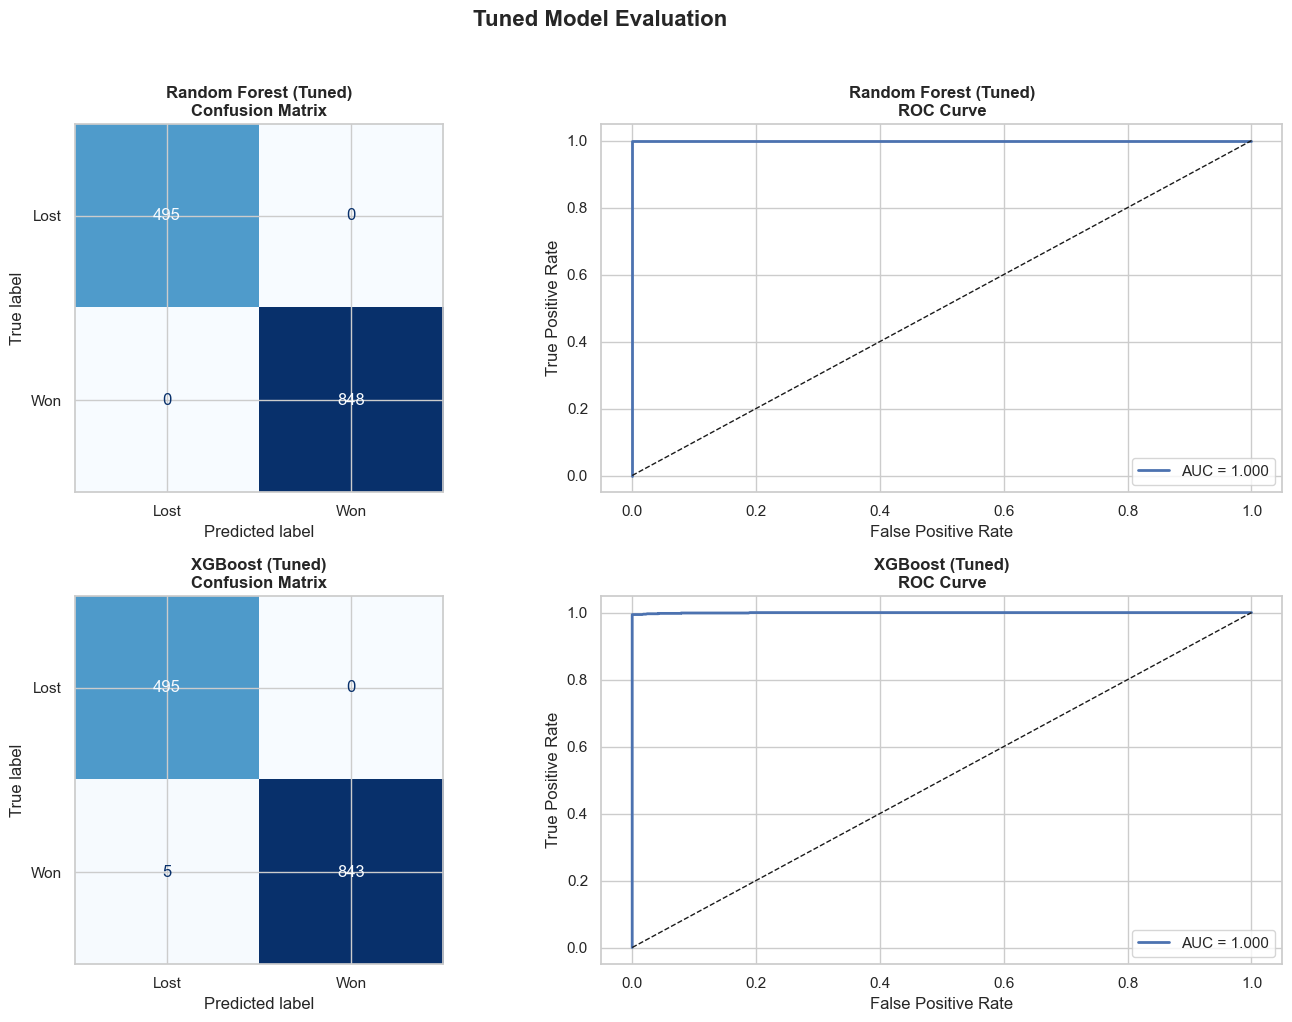

In [56]:
tuned_models = {
    'Random Forest (Tuned)': rf_search.best_estimator_,
    'XGBoost (Tuned)'      : xgb_search.best_estimator_
}

tuned_results = []

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
plot_idx = 0

for name, model in tuned_models.items():
    y_pred      = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]
    test_auc    = roc_auc_score(y_test, y_pred_prob)
    
    tuned_results.append({
        'Model'   : name,
        'Test AUC': round(test_auc, 4),
    })
    
    print(f"\n=== {name} ===")
    print(classification_report(y_test, y_pred, target_names=['Lost', 'Won']))
    print(f"Test AUC: {test_auc:.4f}")
    
    # Confusion matrix
    ConfusionMatrixDisplay(
        confusion_matrix(y_test, y_pred),
        display_labels=['Lost', 'Won']
    ).plot(ax=axes[plot_idx], colorbar=False, cmap='Blues')
    axes[plot_idx].set_title(f'{name}\nConfusion Matrix', fontweight='bold')
    plot_idx += 1
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
    axes[plot_idx].plot(fpr, tpr, lw=2, label=f'AUC = {test_auc:.3f}')
    axes[plot_idx].plot([0,1], [0,1], 'k--', lw=1)
    axes[plot_idx].set_title(f'{name}\nROC Curve', fontweight='bold')
    axes[plot_idx].set_xlabel('False Positive Rate')
    axes[plot_idx].set_ylabel('True Positive Rate')
    axes[plot_idx].legend()
    plot_idx += 1

plt.suptitle('Tuned Model Evaluation', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Final Model Shootout Summary ##

In [57]:
# Compare baseline vs tuned
baseline_xgb_auc = results_df[results_df['Model'] == 'XGBoost']['Test AUC'].values[0]
baseline_rf_auc  = results_df[results_df['Model'] == 'Random Forest']['Test AUC'].values[0]
tuned_xgb_auc    = tuned_results[1]['Test AUC']
tuned_rf_auc     = tuned_results[0]['Test AUC']

summary = pd.DataFrame([
    {'Model': 'Random Forest', 'Baseline AUC': baseline_rf_auc,
     'Tuned AUC': tuned_rf_auc, 'Improvement': round(tuned_rf_auc - baseline_rf_auc, 4)},
    {'Model': 'XGBoost',       'Baseline AUC': baseline_xgb_auc,
     'Tuned AUC': tuned_xgb_auc, 'Improvement': round(tuned_xgb_auc - baseline_xgb_auc, 4)},
])

print("=" * 55)
print("        BASELINE vs TUNED — FINAL SUMMARY")
print("=" * 55)
display(summary)

# Pick the winner
best = max(tuned_results, key=lambda x: x['Test AUC'])
print(f"\n Best Model: {best['Model']} with Test AUC of {best['Test AUC']}")
print("   → Use this model for deal scoring in Cell 16")

        BASELINE vs TUNED — FINAL SUMMARY


,Model,Baseline AUC,Tuned AUC,Improvement
0,Random Forest,1.00,1.00,0.00
1,XGBoost,1.00,1.00,0.00



 Best Model: Random Forest (Tuned) with Test AUC of 1.0
   → Use this model for deal scoring in Cell 16


##  Evaluate the Model ##

In [58]:
y_pred      = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:, 1]

print("=" * 50)
print("        MODEL EVALUATION")
print("=" * 50)
print(classification_report(y_test, y_pred, target_names=['Lost', 'Won']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_prob):.4f}")

# Cross-validation
cv_scores = cross_val_score(model, X, y, cv=StratifiedKFold(5), scoring='roc_auc')
print(f"\nCross-Val AUC (5-fold): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

        MODEL EVALUATION
              precision    recall  f1-score   support

        Lost       0.99      1.00      0.99       495
         Won       1.00      0.99      1.00       848

    accuracy                           1.00      1343
   macro avg       0.99      1.00      1.00      1343
weighted avg       1.00      1.00      1.00      1343

ROC-AUC Score: 0.9996

Cross-Val AUC (5-fold): 0.9998 ± 0.0001


## Confusion Matrix + ROC Curve ##

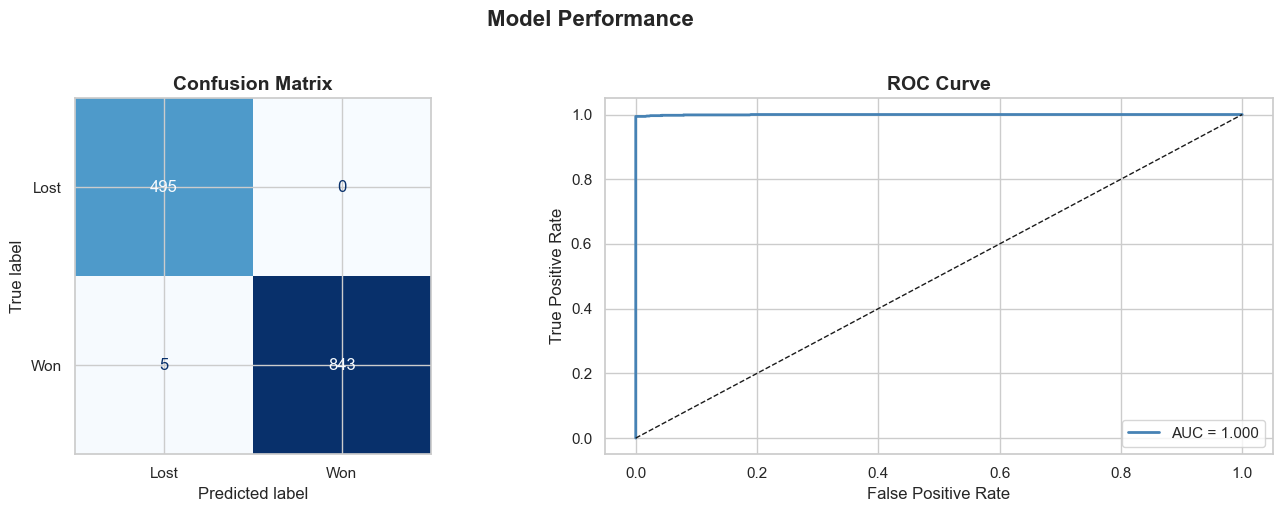

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred),
    display_labels=['Lost', 'Won']
).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix', fontsize=14, fontweight='bold')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
axes[1].plot(fpr, tpr, color='steelblue', lw=2,
             label=f'AUC = {roc_auc_score(y_test, y_pred_prob):.3f}')
axes[1].plot([0,1], [0,1], 'k--', lw=1)
axes[1].set_title('ROC Curve', fontsize=14, fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

plt.suptitle('Model Performance', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('images/07_confusion_roc.png', dpi=150, bbox_inches='tight')
plt.show()

## Feature Importance (What Drives Wins?) ##

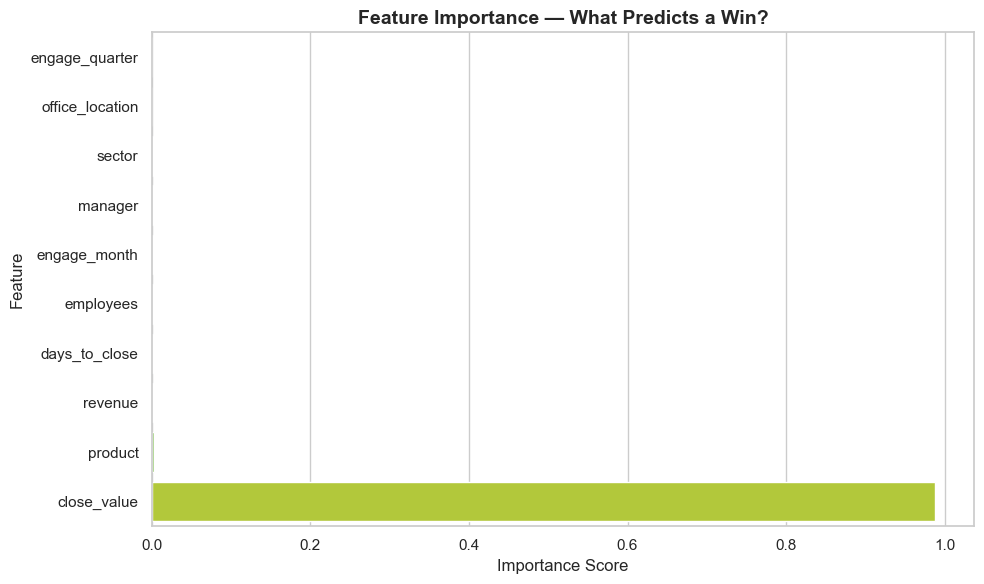


Top 3 predictors of winning a deal:
  close_value: 0.9875
  product: 0.0035
  revenue: 0.0019


In [60]:
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='importance', y='feature', palette='viridis')
plt.title('Feature Importance — What Predicts a Win?', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('images/08_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 3 predictors of winning a deal:")
for i, row in importance_df.tail(3).iloc[::-1].iterrows():
    print(f"  {row['feature']}: {row['importance']:.4f}")

## Score Active Deals (The Business Payoff) ##

   TOP ACTIVE DEALS BY WIN PROBABILITY
   Model: Random Forest (Tuned)


,opportunity_id,sales_agent,product,close_value,win_probability_pct,deal_tier
135,S6645YWA,Kami Bicknell,GTX Basic,0.00,10.30,Low
207,25FUROM1,Daniell Hammack,GTX Plus Basic,0.00,9.30,Low
264,73HO9OZC,Cassey Cress,GTX Basic,0.00,8.80,Low
206,UI3DE2C4,Zane Levy,GTX Plus Basic,0.00,8.70,Low
137,IEAPJ5X1,Maureen Marcano,GTX Plus Basic,0.00,8.70,Low
165,KM1D04JS,James Ascencio,GTX Plus Basic,0.00,8.70,Low
201,EW28ZONV,Zane Levy,GTX Plus Basic,0.00,8.70,Low
142,TF19VML9,Kami Bicknell,GTX Plus Basic,0.00,8.70,Low
209,XRZVJPD5,Maureen Marcano,GTX Plus Basic,0.00,8.70,Low
119,ZHY9C8OO,Kami Bicknell,GTX Plus Basic,0.00,8.70,Low



Pipeline Summary by Tier:
           num_deals  total_pipeline_value
deal_tier                                 
Low             2085                  0.00
Medium             0                  0.00
High               0                  0.00


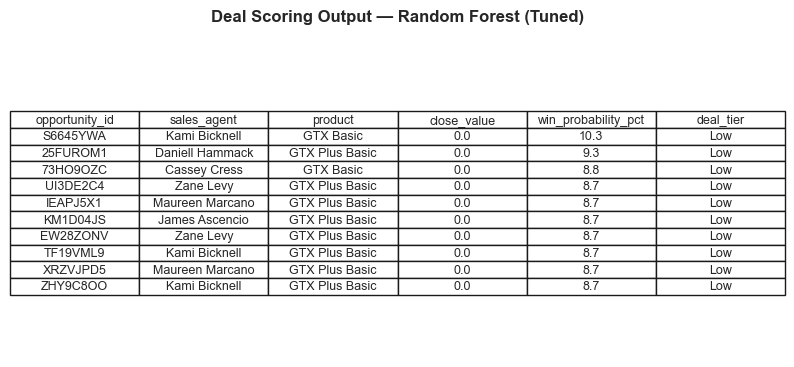

In [65]:
#  Use the winning model from tuning
best_model = rf_search.best_estimator_   # ← Random Forest (Tuned) winner

# Score deals still in pipeline (Prospecting / Engaging)
active = pipeline[pipeline['deal_stage'].isin(['Prospecting', 'Engaging'])].copy()

active['days_to_close'] = (
    pd.Timestamp.today() - active['engage_date']
).dt.days

active['engage_month']   = active['engage_date'].dt.month
active['engage_quarter'] = active['engage_date'].dt.quarter
active['close_value']    = active['close_value'].fillna(0)

active = active.merge(teams, on='sales_agent', how='left')
active = active.merge(
    accounts[['account', 'office_location', 'sector', 'revenue', 'employees']],
    on='account', how='left'
)

active_encoded = active[feature_cols].copy()

for col in cat_cols:
    if col in active_encoded.columns:
        active_encoded[col] = le.fit_transform(active_encoded[col].astype(str))

active_encoded = active_encoded.fillna(0)

# Predict with best model
active['win_probability']     = best_model.predict_proba(active_encoded)[:, 1]
active['win_probability_pct'] = (active['win_probability'] * 100).round(1)

active['deal_tier'] = pd.cut(
    active['win_probability'],
    bins=[0, 0.4, 0.7, 1.0],
    labels=['Low', 'Medium', 'High']
)

# Show top deals
top_deals = (
    active[['opportunity_id', 'sales_agent', 'product',
            'close_value', 'win_probability_pct', 'deal_tier']]
    .sort_values('win_probability_pct', ascending=False)
    .head(15)
)

print("=" * 60)
print("   TOP ACTIVE DEALS BY WIN PROBABILITY")
print("   Model: Random Forest (Tuned)")
print("=" * 60)
display(top_deals)

# Pipeline summary by tier
print("\nPipeline Summary by Tier:")
print(active.groupby('deal_tier', observed=False).agg(
    num_deals=('opportunity_id', 'count'),
    total_pipeline_value=('close_value', 'sum')
).to_string())

# Save screenshot
plt.figure(figsize=(10, 4))
plt.axis('off')
plt.table(
    cellText=top_deals.head(10).values,
    colLabels=top_deals.columns,
    cellLoc='center',
    loc='center'
)
plt.title('Deal Scoring Output — Random Forest (Tuned)', fontweight='bold', pad=20)
plt.savefig('images/09_deal_scoring_output.png', dpi=150, bbox_inches='tight')
plt.show()